<a href="https://colab.research.google.com/github/KeiseanB/healthcare-readmissions-analysis/blob/main/florida_hospital_readmissions_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total records: 18330
Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']
Florida hospitals: 169
Florida hospitals being penalized: 154


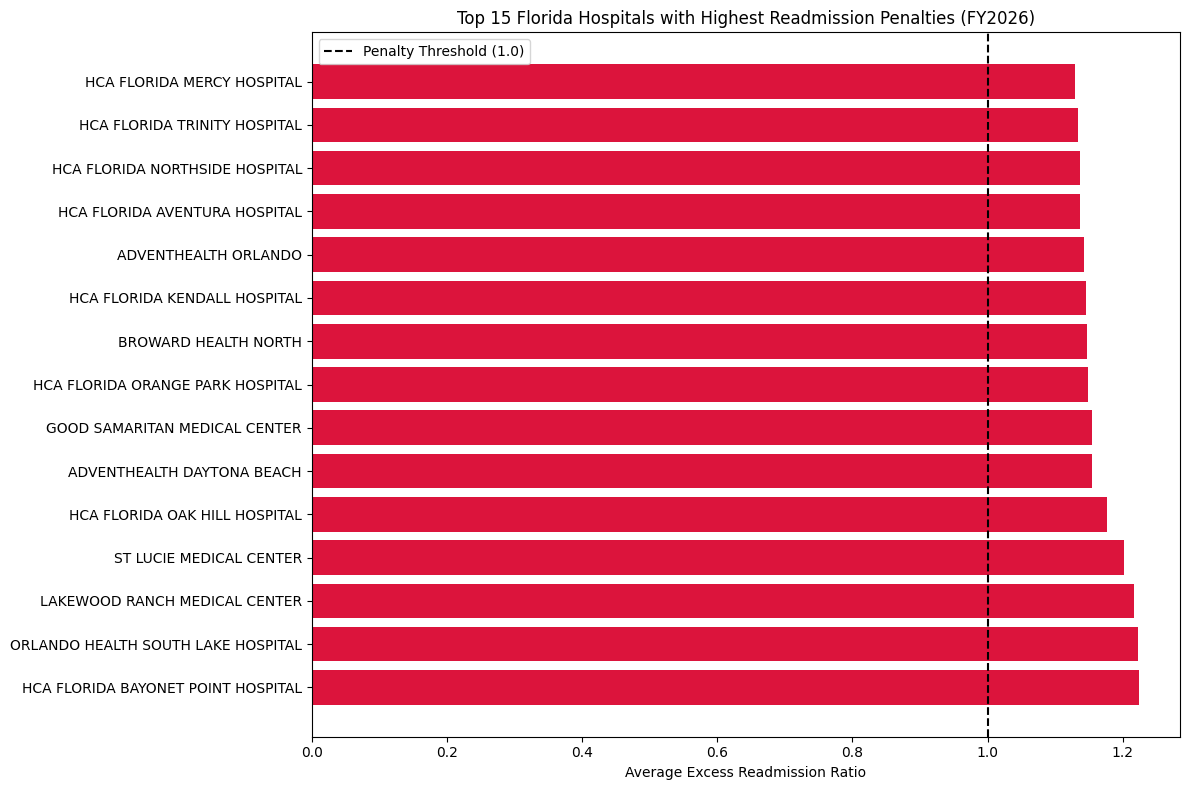

Chart saved!


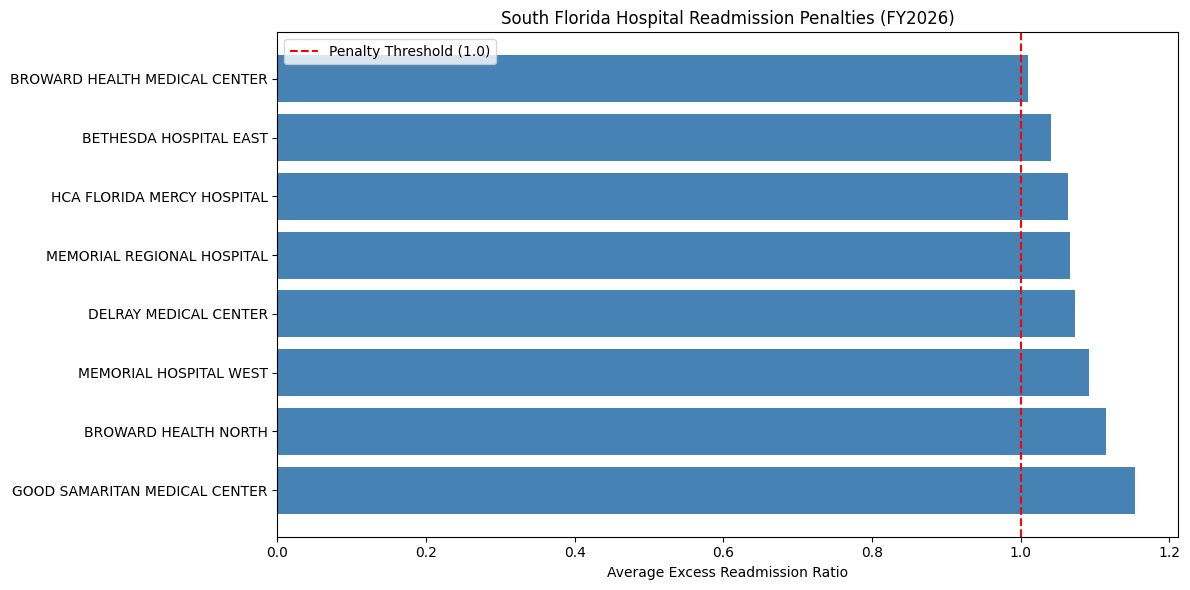

In [5]:
# Block 1 — Import libraries and load the data
import pandas as pd

df = pd.read_csv('FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv')

print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()


# Block 2 — Filter for Florida only
florida = df[df['State'] == 'FL'].copy()

print(f"Florida hospitals: {florida['Facility Name'].nunique()}")
florida.head()


# Block 3 — Find worst performing Florida hospitals (Excess Ratio > 1.0 = penalized)
florida['Excess Readmission Ratio'] = pd.to_numeric(florida['Excess Readmission Ratio'], errors='coerce')

worst = florida[florida['Excess Readmission Ratio'] > 1.0].sort_values('Excess Readmission Ratio', ascending=False)

print(f"Florida hospitals being penalized: {worst['Facility Name'].nunique()}")
worst[['Facility Name', 'Measure Name', 'Excess Readmission Ratio']].head(20)


# Block 4 — Visualize top 15 worst Florida hospitals
import matplotlib.pyplot as plt

top15 = worst.groupby('Facility Name')['Excess Readmission Ratio'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(top15.index, top15.values, color='crimson')
plt.axvline(x=1.0, color='black', linestyle='--', label='Penalty Threshold (1.0)')
plt.xlabel('Average Excess Readmission Ratio')
plt.title('Top 15 Florida Hospitals with Highest Readmission Penalties (FY2026)')
plt.legend()
plt.tight_layout()
plt.savefig('florida_readmissions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")


# Block 5 — South Florida focus (Broward, Miami-Dade, Palm Beach)
south_florida_hospitals = [
    'BROWARD HEALTH NORTH', 'BROWARD HEALTH MEDICAL CENTER',
    'MEMORIAL REGIONAL HOSPITAL', 'MEMORIAL HOSPITAL WEST',
    'DELRAY MEDICAL CENTER', 'GOOD SAMARITAN MEDICAL CENTER',
    'BETHESDA HOSPITAL EAST', 'HCA FLORIDA MERCY HOSPITAL'
]

south_fl = florida[florida['Facility Name'].isin(south_florida_hospitals)]
south_fl_avg = south_fl.groupby('Facility Name')['Excess Readmission Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(south_fl_avg.index, south_fl_avg.values, color='steelblue')
plt.axvline(x=1.0, color='red', linestyle='--', label='Penalty Threshold (1.0)')
plt.xlabel('Average Excess Readmission Ratio')
plt.title('South Florida Hospital Readmission Penalties (FY2026)')
plt.legend()
plt.tight_layout()
plt.show()